# Experiment 1 — Label Efficiency Study (Final Version)
## 6-Model Comparison: Foundation Models vs. Supervised Baselines on Ocular Toxoplasmosis

| | |
|---|---|
| **Models** | RETFound-DINOv2 (2-phase LLRD) · DINOv2-Large · ResNet-50 · ViT-B/16 · EfficientNetV2-S · ConvNeXt-Base |
| **Task** | 3-class: Healthy / Active / Inactive |
| **Label fractions** | 5% · 10% · 25% · 50% · 100% |
| **Primary data** | Data_Raw_6class_All (411 images, 6 folders → 3 classes) |
| **External test** | Dataset V2 / classification (160 images, Healthy vs non-healthy) |

### RETFound-DINOv2 fine-tuning strategy
- **Phase 1 (10 epochs):** Frozen backbone, head-only training, LR=1e-3
- **Phase 2 (30 epochs):** Full model, layer-wise LR decay (base=1e-5, head=1e-3, decay=0.65 per block)
---

## Cell 1 — Install & Environment

In [1]:
import subprocess
def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(('[OK] ' if r.returncode==0 else '[WARN] ') + cmd)
    if r.returncode != 0 and r.stderr: print('  ', r.stderr[:200])

run('pip install -q timm==1.0.3')
run('pip install -q scikit-learn matplotlib seaborn pandas numpy Pillow tqdm')

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT FOUND"}')
if torch.cuda.is_available():
    print(f'VRAM    : {round(torch.cuda.get_device_properties(0).total_memory/1e9,1)} GB')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')

[OK] pip install -q timm==1.0.3
[OK] pip install -q scikit-learn matplotlib seaborn pandas numpy Pillow tqdm
PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : Tesla T4
VRAM    : 15.6 GB
Device  : cuda


## Cell 2 — Imports

In [2]:
import os, random, warnings, copy
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models
import timm

from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
print('All imports OK.')

All imports OK.


## Cell 3 — Dataset Paths & Verification

In [3]:
DS1_ROOT = Path('/kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset')
DS2_ROOT = Path('/kaggle/input/datasets/sakibapon/ocular-toxoplasmosis')
DIR_6CLASS   = DS1_ROOT / 'Data_Raw_6class_All' / 'Data_Raw_6class_All'
DIR_V2_CLASS = DS2_ROOT / 'Dataset V2' / 'classification'
RETFOUND_CKPT = Path('/kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth')
EXTS = {'.jpg','.jpeg','.png','.bmp','.tiff'}

print('── Path verification ──')
for label, p in [('DS1 root', DS1_ROOT),('DS2 root', DS2_ROOT),
                  ('6-class', DIR_6CLASS),('Dataset V2', DIR_V2_CLASS),
                  ('RETFound ckpt', RETFOUND_CKPT)]:
    print(f'  {"[OK]" if p.exists() else "[MISSING]"} {label}: {p}')

print('\n── 6-class image counts ──')
EXPECTED = ['active','active_active','active_inactive','healthy','inactive','inactive_inactive']
total = 0
for d in sorted(DIR_6CLASS.iterdir()):
    if d.is_dir():
        n = len([f for f in d.iterdir() if f.suffix.lower() in EXTS])
        print(f'  {"[OK]" if d.name in EXPECTED else "[?]"} {d.name:25s}: {n}')
        total += n
print(f'  Total: {total}')

if DIR_V2_CLASS.exists():
    print('\n── Dataset V2 ──')
    for sp in sorted(DIR_V2_CLASS.iterdir()):
        if sp.is_dir():
            n = sum(1 for f in sp.rglob('*') if f.suffix.lower() in EXTS)
            print(f'  {sp.name}: {n} images')

── Path verification ──
  [OK] DS1 root: /kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset
  [OK] DS2 root: /kaggle/input/datasets/sakibapon/ocular-toxoplasmosis
  [OK] 6-class: /kaggle/input/datasets/nafin59/ocular-toxoplasmosis-fundus-images-dataset/Data_Raw_6class_All/Data_Raw_6class_All
  [OK] Dataset V2: /kaggle/input/datasets/sakibapon/ocular-toxoplasmosis/Dataset V2/classification
  [OK] RETFound ckpt: /kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth

── 6-class image counts ──
  [OK] active                   : 33
  [OK] active_active            : 1
  [OK] active_inactive          : 57
  [OK] healthy                  : 132
  [OK] inactive                 : 187
  [OK] inactive_inactive        : 1
  Total: 411

── Dataset V2 ──
  train: 128 images
  val: 32 images


## Cell 4 — Config & Transforms

In [4]:
LABEL_FRACS  = [0.05, 0.10, 0.25, 0.50, 1.00]
EPOCHS       = 30       # Phase 2 for RETFound; all epochs for others
PHASE1_EP    = 10       # RETFound Phase 1 (frozen backbone)
BATCH_SIZE   = 16
IMG_SIZE     = 224
LR           = 3e-4     # for non-RETFound models
WEIGHT_DECAY = 0.05
PATIENCE     = 7
Path('/kaggle/working/checkpoints').mkdir(exist_ok=True)

CLASS_NAMES = ['Healthy', 'Active', 'Inactive']
NUM_CLASSES  = 3
PALETTE      = ['#4CAF50','#E53935','#1E88E5']

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = T.Compose([
    T.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
val_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
print('Config ready.')
print(f'Models will run: RETFound-DINOv2 (2-phase LLRD) + 5 supervised/SSL baselines')
print(f'Label fractions: {[str(int(f*100))+"%" for f in LABEL_FRACS]}')

Config ready.
Models will run: RETFound-DINOv2 (2-phase LLRD) + 5 supervised/SSL baselines
Label fractions: ['5%', '10%', '25%', '50%', '100%']


## Cell 5 — Build DataFrames

In [5]:
FOLDER_TO_LABEL = {
    'healthy':0, 'active':1, 'active_active':1,
    'inactive':2, 'inactive_inactive':2, 'active_inactive':2,
}

def build_df_from_6class(root):
    rows = []
    for folder, label in FOLDER_TO_LABEL.items():
        d = root / folder
        if not d.exists(): print(f'  [SKIP] {folder}'); continue
        imgs = [f for f in d.iterdir() if f.suffix.lower() in EXTS]
        print(f'  [OK]  {folder:25s}: {len(imgs):4d} → {CLASS_NAMES[label]}')
        for p in imgs: rows.append({'path':str(p),'label':label,'src':folder})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

def build_df_from_v2(root):
    rows = []
    v2_map = {'healthy':0,'health':0,'active':1,'inactive':2,'non_healthy':2,'diseased':2}
    for sp in sorted(root.iterdir()):
        if not sp.is_dir(): continue
        for cd in sorted(sp.iterdir()):
            if not cd.is_dir(): continue
            label = v2_map.get(cd.name.lower())
            if label is None: print(f'  [WARN] Unknown: {cd.name}'); continue
            imgs = [f for f in cd.iterdir() if f.suffix.lower() in EXTS]
            print(f'  [V2]  {sp.name}/{cd.name:15s} → {CLASS_NAMES[label]} ({len(imgs)})')
            for p in imgs: rows.append({'path':str(p),'label':label,'src':cd.name})
    return pd.DataFrame(rows).sample(frac=1,random_state=SEED).reset_index(drop=True)

print('Building primary dataset:')
df = build_df_from_6class(DIR_6CLASS)
if len(df)==0: raise ValueError('No images loaded!')
print(f'\nTotal: {len(df)}')
for i,n in enumerate(CLASS_NAMES):
    c=(df['label']==i).sum(); print(f'  {i} {n:10s}: {c} ({100*c/len(df):.1f}%)')

ext_df = None
if DIR_V2_CLASS.exists():
    print('\nBuilding external test set:')
    ext_df = build_df_from_v2(DIR_V2_CLASS)
    print(f'External total: {len(ext_df)}')

Building primary dataset:
  [OK]  healthy                  :  132 → Healthy
  [OK]  active                   :   33 → Active
  [OK]  active_active            :    1 → Active
  [OK]  inactive                 :  187 → Inactive
  [OK]  inactive_inactive        :    1 → Inactive
  [OK]  active_inactive          :   57 → Inactive

Total: 411
  0 Healthy   : 132 (32.1%)
  1 Active    : 34 (8.3%)
  2 Inactive  : 245 (59.6%)

Building external test set:
  [V2]  train/healthy         → Healthy (64)
  [V2]  train/non_healthy     → Inactive (64)
  [V2]  val/healthy         → Healthy (16)
  [V2]  val/non_healthy     → Inactive (16)
External total: 160


## Cell 6 — Splits & Loaders

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.40, stratify=df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
train_df=train_df.reset_index(drop=True)
val_df=val_df.reset_index(drop=True)
test_df=test_df.reset_index(drop=True)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
if ext_df is not None: print(f'Ext  : {len(ext_df)}')
for name, sdf in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    counts = [(sdf['label']==i).sum() for i in range(3)]
    print(f'  {name}: H={counts[0]} A={counts[1]} I={counts[2]}')

class OTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df=df.reset_index(drop=True); self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=Image.open(row['path']).convert('RGB')
        if self.transform: img=self.transform(img)
        return img, int(row['label'])

val_loader  = DataLoader(OTDataset(val_df, val_tfm),  batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(OTDataset(test_df, val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
ext_loader  = DataLoader(OTDataset(ext_df,  val_tfm), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True) if ext_df is not None else None
print('Loaders ready.')

Train: 246  Val: 82  Test: 83
Ext  : 160
  Train: H=79 A=20 I=147
  Val: H=26 A=7 I=49
  Test: H=27 A=7 I=49
Loaders ready.


## Cell 7 — Model Builders

In [7]:
# ── Pre-load DINOv2 architecture once to avoid repeated GitHub calls ──────────
print('Pre-loading DINOv2-ViT-L/14 architecture...')
_DINO_ARCH = torch.hub.load('facebookresearch/dinov2','dinov2_vitl14',
                              pretrained=False, trust_repo=True)
print(f'DINOv2 arch cached | embed_dim={_DINO_ARCH.embed_dim}')


# ── 1. RETFound-DINOv2 (2-phase LLRD fine-tuning) ────────────────────────────
def build_retfound_dinov2(num_classes):
    print(f'  Loading RETFound-DINOv2 from {RETFOUND_CKPT}')
    import numpy as np
    torch.serialization.add_safe_globals([np._core.multiarray.scalar])
    try:    ckpt = torch.load(RETFOUND_CKPT, map_location='cpu', weights_only=True)
    except: ckpt = torch.load(RETFOUND_CKPT, map_location='cpu', weights_only=False)

    state = ckpt['model_state_dict']
    # Interpolate pos_embed 36x36 -> 37x37
    pe = state['pos_embed']
    cls_tok  = pe[:,:1,:]
    patch_pe = pe[:,1:,:].reshape(1,36,36,1024).permute(0,3,1,2)
    patch_pe = torch.nn.functional.interpolate(patch_pe,size=(37,37),mode='bicubic',align_corners=False)
    patch_pe = patch_pe.permute(0,2,3,1).reshape(1,1369,1024)
    state['pos_embed'] = torch.cat([cls_tok, patch_pe], dim=1)
    state = {k:v for k,v in state.items() if not k.startswith('head') and not k.startswith('fc')}

    backbone = copy.deepcopy(_DINO_ARCH)
    miss, unex = backbone.load_state_dict(state, strict=False)
    print(f'  Backbone loaded | missing={len(miss)} unexpected={len(unex)}')

    class RETFoundDINOv2(nn.Module):
        def __init__(self, bb, nc):
            super().__init__()
            self.bb=bb; self.head=nn.Linear(bb.embed_dim,nc)
            self.frozen=True; self._freeze_backbone()
        def _freeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad=False
            self.frozen=True
        def _unfreeze_backbone(self):
            for p in self.bb.parameters(): p.requires_grad=True
            self.frozen=False
        def forward(self,x):
            out=self.bb.forward_features(x)
            cls=out['x_norm_clstoken'] if isinstance(out,dict) else out[:,0]
            return self.head(cls)

    model = RETFoundDINOv2(backbone, num_classes)
    print(f'  RETFound-DINOv2 ready | 2-phase LLRD will be used')
    return model


# ── 2. DINOv2-Large (general-domain SSL) ─────────────────────────────────────
def build_dinov2(num_classes):
    print('  Loading DINOv2-Large (pretrained=True)...')
    backbone = torch.hub.load('facebookresearch/dinov2','dinov2_vitl14',
                               pretrained=True,trust_repo=True)
    class DINOv2Clf(nn.Module):
        def __init__(self,bb,nc):
            super().__init__(); self.bb=bb; self.head=nn.Linear(bb.embed_dim,nc)
        def forward(self,x):
            out=self.bb.forward_features(x)
            cls=out['x_norm_clstoken'] if isinstance(out,dict) else out[:,0]
            return self.head(cls)
    print(f'  DINOv2-Large ready | embed_dim={backbone.embed_dim}')
    return DINOv2Clf(backbone,num_classes)


# ── 3. ResNet-50 ──────────────────────────────────────────────────────────────
def build_resnet50(num_classes):
    model=tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc=nn.Linear(model.fc.in_features,num_classes)
    print('  ResNet-50 ready'); return model


# ── 4. ViT-B/16 ───────────────────────────────────────────────────────────────
def build_vitb16(num_classes):
    model=tv_models.vit_b_16(weights=tv_models.ViT_B_16_Weights.IMAGENET1K_V1)
    model.heads.head=nn.Linear(model.heads.head.in_features,num_classes)
    print('  ViT-B/16 ready'); return model


# ── 5. EfficientNetV2-S ───────────────────────────────────────────────────────
def build_efficientnetv2s(num_classes):
    model=tv_models.efficientnet_v2_s(weights=tv_models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    model.classifier[1]=nn.Linear(model.classifier[1].in_features,num_classes)
    print('  EfficientNetV2-S ready'); return model


# ── 6. ConvNeXt-Base ──────────────────────────────────────────────────────────
def build_convnext_base(num_classes):
    model=tv_models.convnext_base(weights=tv_models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
    model.classifier[2]=nn.Linear(model.classifier[2].in_features,num_classes)
    print('  ConvNeXt-Base ready'); return model


MODEL_REGISTRY = {
    'RETFound-DINOv2'  : build_retfound_dinov2,
    'DINOv2-Large'     : build_dinov2,
    'ResNet-50'        : build_resnet50,
    'ViT-B/16'         : build_vitb16,
    'EfficientNetV2-S' : build_efficientnetv2s,
    'ConvNeXt-Base'    : build_convnext_base,
}
print(f'\nModel registry: {list(MODEL_REGISTRY.keys())}')

Pre-loading DINOv2-ViT-L/14 architecture...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
DINOv2 arch cached | embed_dim=1024

Model registry: ['RETFound-DINOv2', 'DINOv2-Large', 'ResNet-50', 'ViT-B/16', 'EfficientNetV2-S', 'ConvNeXt-Base']


## Cell 8 — Pre-Training Verification
> Loads every model once and runs a dummy forward pass before the experiment.

In [8]:
print('='*62)
print('  PRE-TRAINING VERIFICATION')
print('='*62)
verified = {}
for mname, builder in MODEL_REGISTRY.items():
    print(f'\n[{mname}]')
    try:
        m = builder(NUM_CLASSES).to(DEVICE)
        dummy = torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
        with torch.no_grad(): out = m(dummy)
        assert out.shape==(2,NUM_CLASSES), f'Bad shape: {out.shape}'
        print(f'  Forward pass OK | output: {out.shape}')
        verified[mname]=True
        del m; torch.cuda.empty_cache()
    except Exception as e:
        print(f'  [FAILED] {e}')
        verified[mname]=False

print('\n── Summary ──')
all_ok=True
for mname,ok in verified.items():
    print(f'  {"✅" if ok else "❌"}  {mname}')
    if not ok: all_ok=False
if not all_ok:
    raise RuntimeError('Fix failed models before running the experiment.')
print('\nAll models verified. Safe to proceed.')

  PRE-TRAINING VERIFICATION

[RETFound-DINOv2]
  Loading RETFound-DINOv2 from /kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth
  Backbone loaded | missing=1 unexpected=0
  RETFound-DINOv2 ready | 2-phase LLRD will be used
  Forward pass OK | output: torch.Size([2, 3])

[DINOv2-Large]
  Loading DINOv2-Large (pretrained=True)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:03<00:00, 364MB/s]


  DINOv2-Large ready | embed_dim=1024
  Forward pass OK | output: torch.Size([2, 3])

[ResNet-50]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


...

  ViT-B/16 ready
  Forward pass OK | output: torch.Size([2, 3])

[EfficientNetV2-S]
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 195MB/s]


  EfficientNetV2-S ready
  Forward pass OK | output: torch.Size([2, 3])

[ConvNeXt-Base]
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:02<00:00, 173MB/s]


  ConvNeXt-Base ready
  Forward pass OK | output: torch.Size([2, 3])

── Summary ──
  ✅  RETFound-DINOv2
  ✅  DINOv2-Large
  ✅  ResNet-50
  ✅  ViT-B/16
  ✅  EfficientNetV2-S
  ✅  ConvNeXt-Base

All models verified. Safe to proceed.


## Cell 9 — Training & Evaluation Helpers

In [9]:
def get_class_weights(sdf):
    counts=np.array([(sdf['label']==i).sum() for i in range(NUM_CLASSES)],dtype=float)
    counts=np.where(counts==0,1,counts); w=1.0/counts
    return torch.tensor(w/w.sum()*NUM_CLASSES,dtype=torch.float32).to(DEVICE)

def train_one_epoch(model,loader,criterion,optimizer,scaler):
    model.train(); total_loss=correct=total=0
    for imgs,labels in loader:
        imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out=model(imgs); loss=criterion(out,labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss+=loss.item()*len(labels)
        correct+=(out.argmax(1)==labels).sum().item(); total+=len(labels)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model,loader):
    model.eval(); all_logits,all_labels=[],[]
    for imgs,labels in loader:
        all_logits.append(model(imgs.to(DEVICE)).cpu()); all_labels.append(labels)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    probs=torch.softmax(logits,1).numpy(); preds=logits.argmax(1).numpy()
    acc=accuracy_score(labels,preds)
    f1=f1_score(labels,preds,average='macro',zero_division=0)
    try: auc=roc_auc_score(labels,probs,multi_class='ovr',average='macro')
    except: auc=float('nan')
    return acc,f1,auc,preds,labels,probs

def get_llrd_optimizer(model, base_lr=1e-5, head_lr=1e-3, decay=0.65, wd=0.05):
    param_groups=[]
    param_groups.append({'params':list(model.head.parameters()),'lr':head_lr,'name':'head'})
    param_groups.append({'params':list(model.bb.norm.parameters()),'lr':base_lr*(decay**0),'name':'norm'})
    num_blocks=len(model.bb.blocks)
    for i,block in enumerate(reversed(model.bb.blocks)):
        lr_i=base_lr*(decay**(i+1))
        param_groups.append({'params':list(block.parameters()),'lr':lr_i,'name':f'block_{num_blocks-1-i}'})
    other=[p for p in (list(model.bb.patch_embed.parameters())+
                        [model.bb.cls_token,model.bb.pos_embed]) if p.requires_grad]
    if other: param_groups.append({'params':other,'lr':base_lr*(decay**(num_blocks+1)),'name':'embed'})
    return optim.AdamW(param_groups,weight_decay=wd)

def train_model(model_name, subset_df):
    set_seed(SEED)
    model=MODEL_REGISTRY[model_name](NUM_CLASSES).to(DEVICE)
    train_ds=OTDataset(subset_df,train_tfm)
    train_ld=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,
                         num_workers=2,pin_memory=True,
                         drop_last=len(train_ds)>=BATCH_SIZE)
    weights=get_class_weights(subset_df)
    criterion=nn.CrossEntropyLoss(weight=weights)
    scaler=torch.cuda.amp.GradScaler()
    is_retfound=hasattr(model,'frozen')
    history=[]

    # ── Phase 1: frozen backbone, head-only (RETFound only) ───────────────────
    if is_retfound:
        print(f'  [P1] Frozen backbone, head-only LR=1e-3 ({PHASE1_EP} epochs)')
        opt1=optim.AdamW(model.head.parameters(),lr=1e-3,weight_decay=WEIGHT_DECAY)
        sch1=optim.lr_scheduler.CosineAnnealingLR(opt1,T_max=PHASE1_EP)
        for epoch in range(1,PHASE1_EP+1):
            tr_loss,tr_acc=train_one_epoch(model,train_ld,criterion,opt1,scaler)
            val_acc,val_f1,val_auc,*_=evaluate(model,val_loader)
            sch1.step()
            history.append(dict(epoch=epoch,phase=1,tr_loss=tr_loss,tr_acc=tr_acc,
                                 val_acc=val_acc,val_f1=val_f1,val_auc=val_auc))
            if epoch%5==0 or epoch==1:
                print(f'    [P1] E{epoch:02d} | loss={tr_loss:.4f} | val_auc={val_auc:.3f}')

    # ── Phase 2: full model (LLRD for RETFound, standard for others) ──────────
    if is_retfound:
        model._unfreeze_backbone()
        optimizer=get_llrd_optimizer(model,base_lr=1e-5,head_lr=1e-3,decay=0.65)
        print(f'  [P2] Full model LLRD, base_lr=1e-5, head_lr=1e-3 ({EPOCHS} epochs)')
        epoch_offset=PHASE1_EP
    else:
        optimizer=optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
        epoch_offset=0

    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
    best_auc=0.0; best_state=None; wait=0

    for epoch in range(1,EPOCHS+1):
        tr_loss,tr_acc=train_one_epoch(model,train_ld,criterion,optimizer,scaler)
        val_acc,val_f1,val_auc,*_=evaluate(model,val_loader)
        scheduler.step()
        phase_lbl='P2' if is_retfound else 'P1'
        history.append(dict(epoch=epoch+epoch_offset,phase=2 if is_retfound else 1,
                             tr_loss=tr_loss,tr_acc=tr_acc,
                             val_acc=val_acc,val_f1=val_f1,val_auc=val_auc))
        if val_auc>best_auc:
            best_auc=val_auc; best_state=deepcopy(model.state_dict()); wait=0
        else:
            wait+=1
            if wait>=PATIENCE:
                print(f'    Early stop @ epoch {epoch+epoch_offset}  best_val_auc={best_auc:.4f}')
                break
        if epoch%5==0 or epoch==1:
            print(f'    [{phase_lbl}] E{epoch+epoch_offset:02d} | loss={tr_loss:.4f} | '
                  f'val_acc={val_acc:.3f} | val_f1={val_f1:.3f} | val_auc={val_auc:.3f}')

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

print('Training helpers defined. train_model version: TWO-PHASE LLRD')

Training helpers defined. train_model version: TWO-PHASE LLRD


## Cell 10 — Run Experiment 1

> **Estimated runtime on T4:** ~2.5–3 hrs total (RETFound ~90 min, others ~30 min each)  
> Results CSV is saved after every sub-run.

In [10]:
all_results=[]; best_models={}; all_histories={}

for model_name in MODEL_REGISTRY:
    print(f'\n{"="*62}')
    print(f'  MODEL: {model_name}')
    print(f'{"="*62}')

    for frac in LABEL_FRACS:
        if frac<1.0:
            sub_df,_=train_test_split(train_df,train_size=frac,
                                       stratify=train_df['label'],random_state=SEED)
        else:
            sub_df=train_df.copy()
        sub_df=sub_df.reset_index(drop=True)

        if sub_df['label'].nunique()<NUM_CLASSES:
            print(f'  [SKIP] {int(frac*100)}%: not all classes represented'); continue

        n_h=(sub_df['label']==0).sum(); n_a=(sub_df['label']==1).sum(); n_i=(sub_df['label']==2).sum()
        print(f'\n  {int(frac*100):3d}% | n={len(sub_df):4d} | H={n_h} A={n_a} I={n_i}')

        model,history=train_model(model_name,sub_df)

        test_acc,test_f1,test_auc,preds,labels,probs=evaluate(model,test_loader)
        print(f'  INTERNAL TEST → acc={test_acc:.4f}  f1={test_f1:.4f}  auc={test_auc:.4f}')

        row=dict(Model=model_name,Fraction=frac,Pct=int(frac*100),N_Train=len(sub_df),
                 Test_ACC=round(test_acc,4),Test_F1=round(test_f1,4),Test_AUC=round(test_auc,4))

        if ext_loader:
            ext_acc,ext_f1,ext_auc,*_=evaluate(model,ext_loader)
            print(f'  EXTERNAL TEST  → acc={ext_acc:.4f}  f1={ext_f1:.4f}  auc={ext_auc:.4f}')
            row.update(Ext_ACC=round(ext_acc,4),Ext_F1=round(ext_f1,4),Ext_AUC=round(ext_auc,4))

        all_results.append(row)
        pd.DataFrame(all_results).to_csv('/kaggle/working/experiment1_results.csv',index=False)
        all_histories[(model_name,frac)]=history
        if frac==1.0: best_models[model_name]=(model.cpu(),preds,labels,probs)

        del model; torch.cuda.empty_cache()

results_df=pd.DataFrame(all_results)
print('\n\n✅ ALL RUNS COMPLETE')
print(results_df.to_string(index=False))


  MODEL: RETFound-DINOv2

    5% | n=  12 | H=4 A=1 I=7
  Loading RETFound-DINOv2 from /kaggle/input/models/hangtai/retfound-dinov2/pytorch/default/1/RETFound_dinov2_20260402_221651/checkpoints/best_model.pth
  Backbone loaded | missing=1 unexpected=0
  RETFound-DINOv2 ready | 2-phase LLRD will be used
  [P1] Frozen backbone, head-only LR=1e-3 (10 epochs)
    [P1] E01 | loss=1.6437 | val_auc=0.468
    [P1] E05 | loss=0.6007 | val_auc=0.560
    [P1] E10 | loss=0.5010 | val_auc=0.592
  [P2] Full model LLRD, base_lr=1e-5, head_lr=1e-3 (30 epochs)
    [P2] E11 | loss=0.4755 | val_acc=0.463 | val_f1=0.360 | val_auc=0.641
    [P2] E15 | loss=0.1657 | val_acc=0.598 | val_f1=0.453 | val_auc=0.728
    [P2] E20 | loss=0.0396 | val_acc=0.634 | val_f1=0.478 | val_auc=0.755
    [P2] E25 | loss=0.0163 | val_acc=0.683 | val_f1=0.513 | val_auc=0.767
    [P2] E30 | loss=0.0051 | val_acc=0.707 | val_f1=0.532 | val_auc=0.771
    [P2] E35 | loss=0.0097 | val_acc=0.707 | val_f1=0.532 | val_auc=0.773
    [

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  DINOv2-Large ready | embed_dim=1024
    [P1] E01 | loss=1.2231 | val_acc=0.159 | val_f1=0.127 | val_auc=0.350
    [P1] E05 | loss=8.9891 | val_acc=0.085 | val_f1=0.052 | val_auc=0.471
    Early stop @ epoch 9  best_val_auc=0.5770
  INTERNAL TEST → acc=0.3253  f1=0.1636  auc=0.5149
  EXTERNAL TEST  → acc=0.5000  f1=0.3333  auc=nan

   10% | n=  24 | H=8 A=2 I=14
  Loading DINOv2-Large (pretrained=True)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  DINOv2-Large ready | embed_dim=1024
    [P1] E01 | loss=1.3960 | val_acc=0.159 | val_f1=0.127 | val_auc=0.350
    [P1] E05 | loss=12.5293 | val_acc=0.317 | val_f1=0.160 | val_auc=0.446
    [P1] E10 | loss=1.2870 | val_acc=0.085 | val_f1=0.052 | val_auc=0.464
    [P1] E15 | loss=1.0909 | val_acc=0.598 | val_f1=0.249 | val_auc=0.500
    Early stop @ epoch 19  best_val_auc=0.5598
  INTERNAL TEST → acc=0.5904  f1=0.2475  auc=0.5444
  EXTERNAL TEST  → acc=0.5000  f1=0.3333  auc=nan

   25% | n=  61 | H=20 A=5 I=36
  Loading DINOv2-Large (pretrained=True)...


...

  DINOv2-Large ready | embed_dim=1024
    [P1] E01 | loss=4.4376 | val_acc=0.317 | val_f1=0.160 | val_auc=0.452
    [P1] E05 | loss=1.2125 | val_acc=0.598 | val_f1=0.249 | val_auc=0.481
    [P1] E10 | loss=1.3462 | val_acc=0.329 | val_f1=0.175 | val_auc=0.517
    [P1] E15 | loss=1.1126 | val_acc=0.317 | val_f1=0.170 | val_auc=0.523
    [P1] E20 | loss=1.0866 | val_acc=0.512 | val_f1=0.228 | val_auc=0.542
    [P1] E25 | loss=1.0963 | val_acc=0.280 | val_f1=0.217 | val_auc=0.541
    Early stop @ epoch 30  best_val_auc=0.5616
  INTERNAL TEST → acc=0.4578  f1=0.3179  auc=0.5591
  EXTERNAL TEST  → acc=0.5437  f1=0.4965  auc=nan

   50% | n= 123 | H=39 A=10 I=74
  Loading DINOv2-Large (pretrained=True)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  DINOv2-Large ready | embed_dim=1024
    [P1] E01 | loss=4.4708 | val_acc=0.317 | val_f1=0.160 | val_auc=0.527
    [P1] E05 | loss=1.1944 | val_acc=0.317 | val_f1=0.160 | val_auc=0.589
    [P1] E10 | loss=1.0903 | val_acc=0.598 | val_f1=0.249 | val_auc=0.660
    [P1] E15 | loss=1.0445 | val_acc=0.573 | val_f1=0.500 | val_auc=0.724
    [P1] E20 | loss=0.9683 | val_acc=0.512 | val_f1=0.461 | val_auc=0.705
    [P1] E25 | loss=0.8898 | val_acc=0.634 | val_f1=0.560 | val_auc=0.794
    [P1] E30 | loss=0.8628 | val_acc=0.634 | val_f1=0.558 | val_auc=0.788
  INTERNAL TEST → acc=0.5542  f1=0.4421  auc=0.7181
  EXTERNAL TEST  → acc=0.7812  f1=0.5304  auc=nan

  100% | n= 246 | H=79 A=20 I=147
  Loading DINOv2-Large (pretrained=True)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  DINOv2-Large ready | embed_dim=1024
    [P1] E01 | loss=4.4780 | val_acc=0.598 | val_f1=0.249 | val_auc=0.582
    [P1] E05 | loss=1.1462 | val_acc=0.085 | val_f1=0.052 | val_auc=0.682
    [P1] E10 | loss=1.0883 | val_acc=0.610 | val_f1=0.530 | val_auc=0.680
    [P1] E15 | loss=1.0359 | val_acc=0.329 | val_f1=0.278 | val_auc=0.701
    [P1] E20 | loss=0.8825 | val_acc=0.549 | val_f1=0.466 | val_auc=0.777
    [P1] E25 | loss=0.7463 | val_acc=0.646 | val_f1=0.544 | val_auc=0.801
    [P1] E30 | loss=0.6830 | val_acc=0.671 | val_f1=0.631 | val_auc=0.799
  INTERNAL TEST → acc=0.5904  f1=0.5016  auc=0.7520
  EXTERNAL TEST  → acc=0.7625  f1=0.5226  auc=nan

  MODEL: ResNet-50

    5% | n=  12 | H=4 A=1 I=7
  ResNet-50 ready
    [P1] E01 | loss=1.1240 | val_acc=0.512 | val_f1=0.355 | val_auc=0.606
    [P1] E05 | loss=0.7638 | val_acc=0.610 | val_f1=0.296 | val_auc=0.704
    [P1] E10 | loss=0.2791 | val_acc=0.610 | val_f1=0.296 | val_auc=0.713
    [P1] E15 | loss=0.1167 | val_acc=0.634 | val_f1

## Cell 11 — Figure 1: Label Efficiency Curves

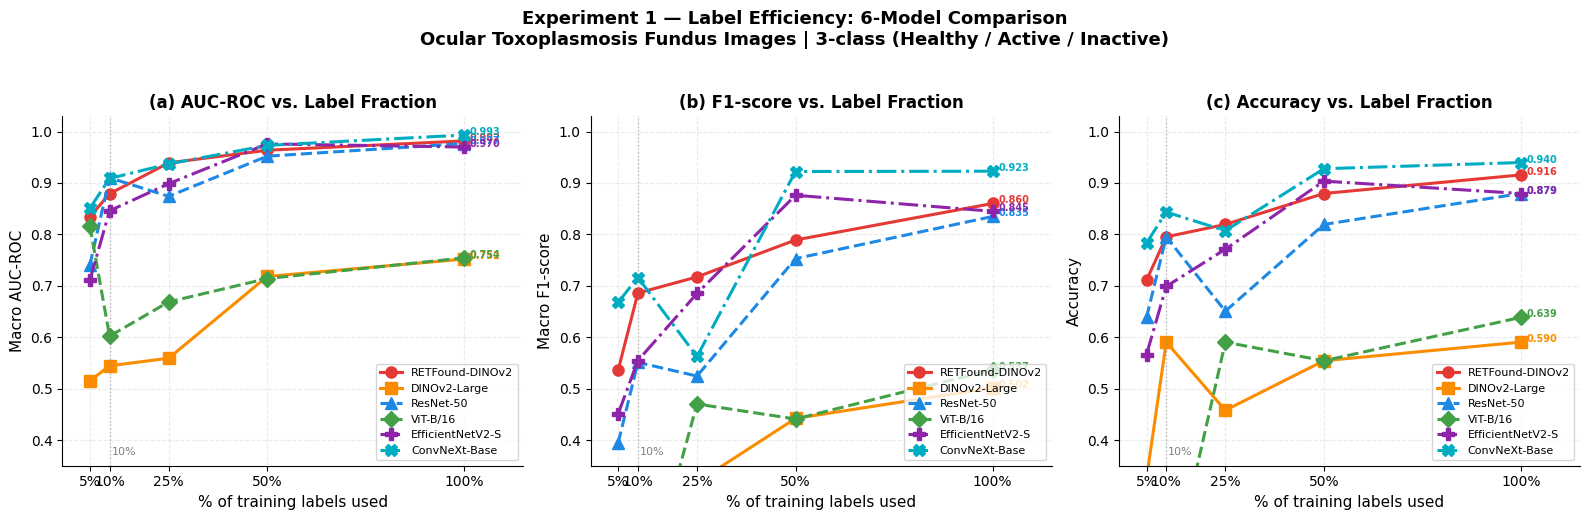

Figure 1 saved.


In [11]:
MODEL_COLORS={
    'RETFound-DINOv2':'#E53935','DINOv2-Large':'#FB8C00',
    'ResNet-50':'#1E88E5','ViT-B/16':'#43A047',
    'EfficientNetV2-S':'#8E24AA','ConvNeXt-Base':'#00ACC1'
}
MODEL_MARKERS={'RETFound-DINOv2':'o','DINOv2-Large':'s','ResNet-50':'^',
               'ViT-B/16':'D','EfficientNetV2-S':'P','ConvNeXt-Base':'X'}
MODEL_LS={'RETFound-DINOv2':'-','DINOv2-Large':'-','ResNet-50':'--',
          'ViT-B/16':'--','EfficientNetV2-S':'-.','ConvNeXt-Base':'-.'}

METRICS=[('Test_AUC','Macro AUC-ROC','(a) AUC-ROC vs. Label Fraction'),
          ('Test_F1', 'Macro F1-score','(b) F1-score vs. Label Fraction'),
          ('Test_ACC','Accuracy',      '(c) Accuracy vs. Label Fraction')]

fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,(metric,ylabel,title) in zip(axes,METRICS):
    for mname in MODEL_REGISTRY:
        sub=results_df[results_df['Model']==mname].sort_values('Fraction')
        if len(sub)==0: continue
        ax.plot(sub['Pct'],sub[metric],
                color=MODEL_COLORS[mname],marker=MODEL_MARKERS[mname],
                linestyle=MODEL_LS[mname],linewidth=2.2,markersize=8,label=mname)
        last=sub[sub['Pct']==100]
        if len(last):
            ax.annotate(f"{last[metric].values[0]:.3f}",
                        xy=(100,last[metric].values[0]),xytext=(4,0),
                        textcoords='offset points',fontsize=7,
                        color=MODEL_COLORS[mname],fontweight='bold')
    ax.axvline(x=10,color='gray',linestyle=':',alpha=0.5,linewidth=1)
    ax.text(10.5,0.37,'10%',fontsize=8,color='gray')
    ax.set_xlabel('% of training labels used',fontsize=11)
    ax.set_ylabel(ylabel,fontsize=11)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_xticks([5,10,25,50,100])
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
    ax.set_xlim(-2,115); ax.set_ylim(0.35,1.03)
    ax.legend(fontsize=8,loc='lower right')
    ax.grid(True,alpha=0.25,linestyle='--')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 1 — Label Efficiency: 6-Model Comparison\n'
             'Ocular Toxoplasmosis Fundus Images | 3-class (Healthy / Active / Inactive)',
             fontsize=13,fontweight='bold',y=1.03)
plt.tight_layout()
plt.savefig('/kaggle/working/fig1_label_efficiency.png',dpi=150,bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## Cell 12 — Figure 2: AUC & F1 Heatmaps

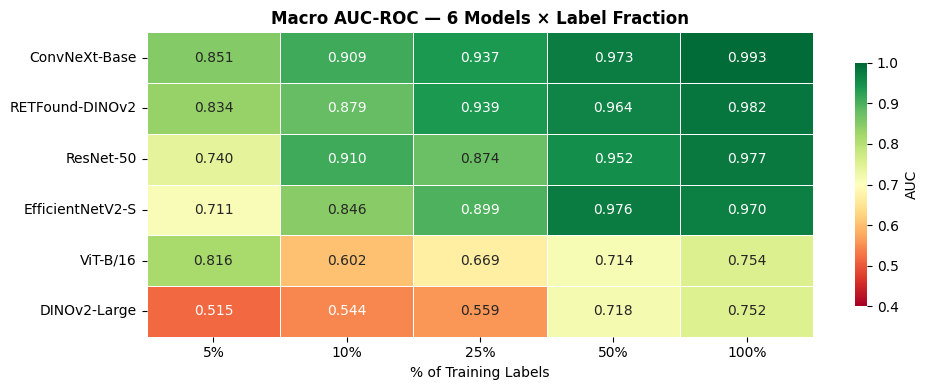

                     5%    10%    25%    50%   100%
Model                                              
ConvNeXt-Base     0.851  0.909  0.937  0.973  0.993
RETFound-DINOv2   0.834  0.879  0.939  0.964  0.982
ResNet-50         0.740  0.910  0.874  0.952  0.977
EfficientNetV2-S  0.711  0.846  0.899  0.976  0.970
ViT-B/16          0.816  0.602  0.669  0.714  0.754
DINOv2-Large      0.515  0.544  0.559  0.718  0.752


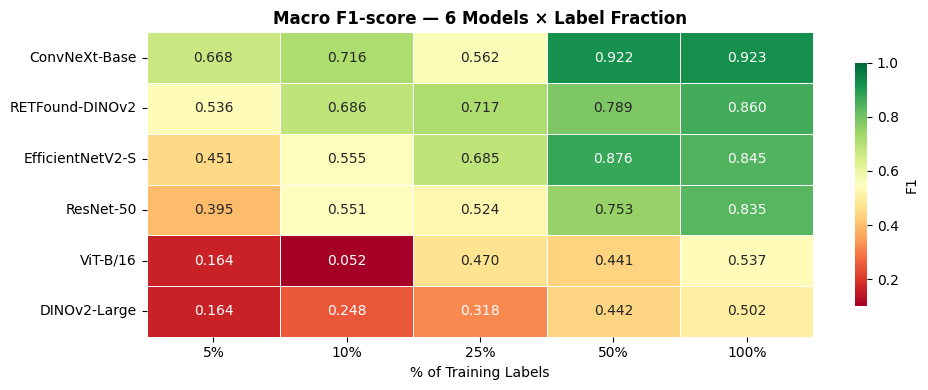

                     5%    10%    25%    50%   100%
Model                                              
ConvNeXt-Base     0.668  0.716  0.562  0.922  0.923
RETFound-DINOv2   0.536  0.686  0.717  0.789  0.860
EfficientNetV2-S  0.451  0.555  0.685  0.876  0.845
ResNet-50         0.395  0.551  0.524  0.753  0.835
ViT-B/16          0.164  0.052  0.470  0.441  0.537
DINOv2-Large      0.164  0.248  0.318  0.442  0.502


In [12]:
def make_heatmap(metric,title,fname,vmin,vmax):
    pivot=results_df.pivot_table(index='Model',columns='Pct',values=metric).round(3)
    pivot.columns=[f'{c}%' for c in pivot.columns]
    pivot=pivot.sort_values('100%',ascending=False)
    fig,ax=plt.subplots(figsize=(10,4))
    sns.heatmap(pivot,annot=True,fmt='.3f',cmap='RdYlGn',vmin=vmin,vmax=vmax,
                linewidths=0.6,ax=ax,cbar_kws={'label':metric.replace('Test_',''),'shrink':0.8})
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_xlabel('% of Training Labels'); ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{fname}',dpi=150,bbox_inches='tight')
    plt.show()
    print(pivot.to_string())

make_heatmap('Test_AUC','Macro AUC-ROC — 6 Models × Label Fraction','fig2a_auc_heatmap.png',0.40,1.00)
make_heatmap('Test_F1', 'Macro F1-score — 6 Models × Label Fraction','fig2b_f1_heatmap.png', 0.10,1.00)

## Cell 13 — Figure 3: Performance Degradation

                  AUC@100%  AUC@5%  Drop@5%  AUC@10%  Drop@10%  AUC@25%  Drop@25%
Model                                                                            
RETFound-DINOv2      0.982   0.834    0.148    0.879     0.103    0.939     0.043
DINOv2-Large         0.752   0.515    0.237    0.544     0.208    0.559     0.193
ResNet-50            0.977   0.740    0.236    0.910     0.067    0.874     0.103
ViT-B/16             0.754   0.816   -0.062    0.602     0.152    0.669     0.086
EfficientNetV2-S     0.970   0.711    0.259    0.846     0.124    0.899     0.071
ConvNeXt-Base        0.993   0.851    0.142    0.909     0.085    0.937     0.056


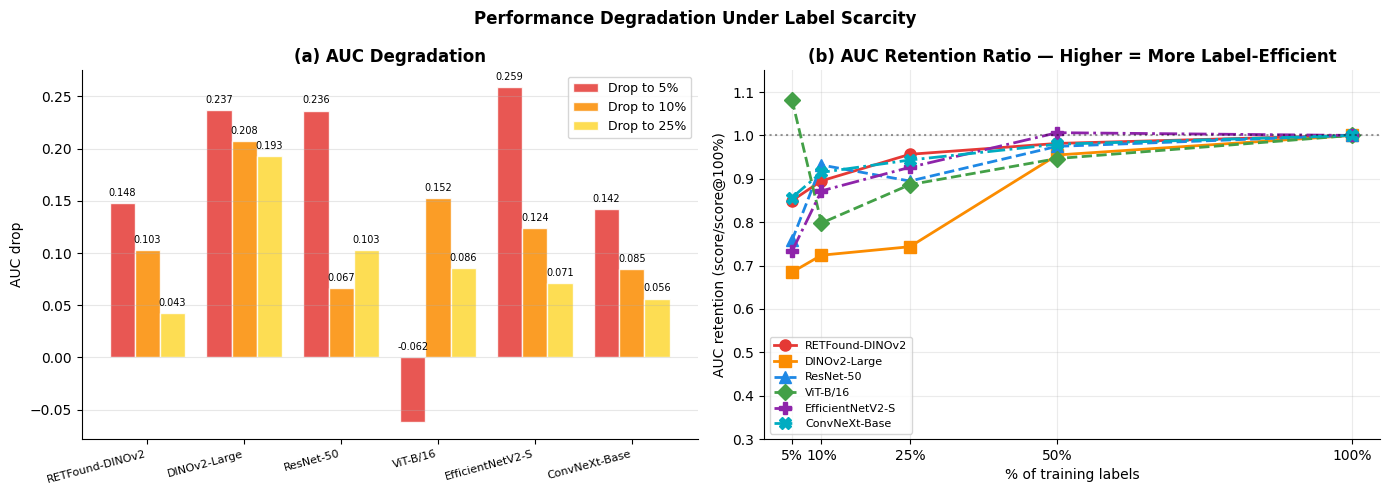

In [13]:
ref_pcts=[5,10,25]
base_100=results_df[results_df['Pct']==100].set_index('Model')['Test_AUC']
deg_rows=[]
for mname in MODEL_REGISTRY:
    row={'Model':mname,'AUC@100%':base_100.get(mname,float('nan'))}
    for pct in ref_pcts:
        sub=results_df[(results_df['Model']==mname)&(results_df['Pct']==pct)]
        val=sub.iloc[0]['Test_AUC'] if len(sub) else float('nan')
        row[f'AUC@{pct}%']=val
        row[f'Drop@{pct}%']=round(base_100.get(mname,float('nan'))-val,4)
    deg_rows.append(row)
deg_df=pd.DataFrame(deg_rows).set_index('Model')
print(deg_df.round(3).to_string())

fig,axes=plt.subplots(1,2,figsize=(14,5))
x=np.arange(len(deg_df)); w=0.26; colors_bar=['#E53935','#FB8C00','#FDD835']
ax=axes[0]
for i,pct in enumerate(ref_pcts):
    vals=deg_df[f'Drop@{pct}%'].values
    bars=ax.bar(x+(i-1)*w,vals,w,label=f'Drop to {pct}%',
                 color=colors_bar[i],alpha=0.85,edgecolor='white')
    for bar,v in zip(bars,vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2,max(v,0)+0.005,
                    f'{v:.3f}',ha='center',va='bottom',fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(deg_df.index,fontsize=8,rotation=15,ha='right')
ax.set_ylabel('AUC drop'); ax.set_title('(a) AUC Degradation',fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3); ax.spines[['top','right']].set_visible(False)

ax=axes[1]
for mname in MODEL_REGISTRY:
    fracs,ratios=[],[]
    base=base_100.get(mname,1.0)
    for frac in LABEL_FRACS:
        sub=results_df[(results_df['Model']==mname)&(results_df['Fraction']==frac)]
        if len(sub) and base>0:
            fracs.append(frac*100); ratios.append(sub.iloc[0]['Test_AUC']/base)
    if fracs:
        ax.plot(fracs,ratios,color=MODEL_COLORS[mname],marker=MODEL_MARKERS[mname],
                linestyle=MODEL_LS[mname],linewidth=2,markersize=8,label=mname)
ax.axhline(y=1.0,color='black',linestyle=':',alpha=0.4)
ax.set_xlabel('% of training labels'); ax.set_ylabel('AUC retention (score/score@100%)')
ax.set_title('(b) AUC Retention Ratio — Higher = More Label-Efficient',fontweight='bold')
ax.set_xticks([5,10,25,50,100]); ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d%%'))
ax.set_ylim(0.3,1.15); ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.spines[['top','right']].set_visible(False)
plt.suptitle('Performance Degradation Under Label Scarcity',fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fig3_degradation.png',dpi=150,bbox_inches='tight')
plt.show()

## Cell 14 — Figure 4: Confusion Matrices @ 100% Labels

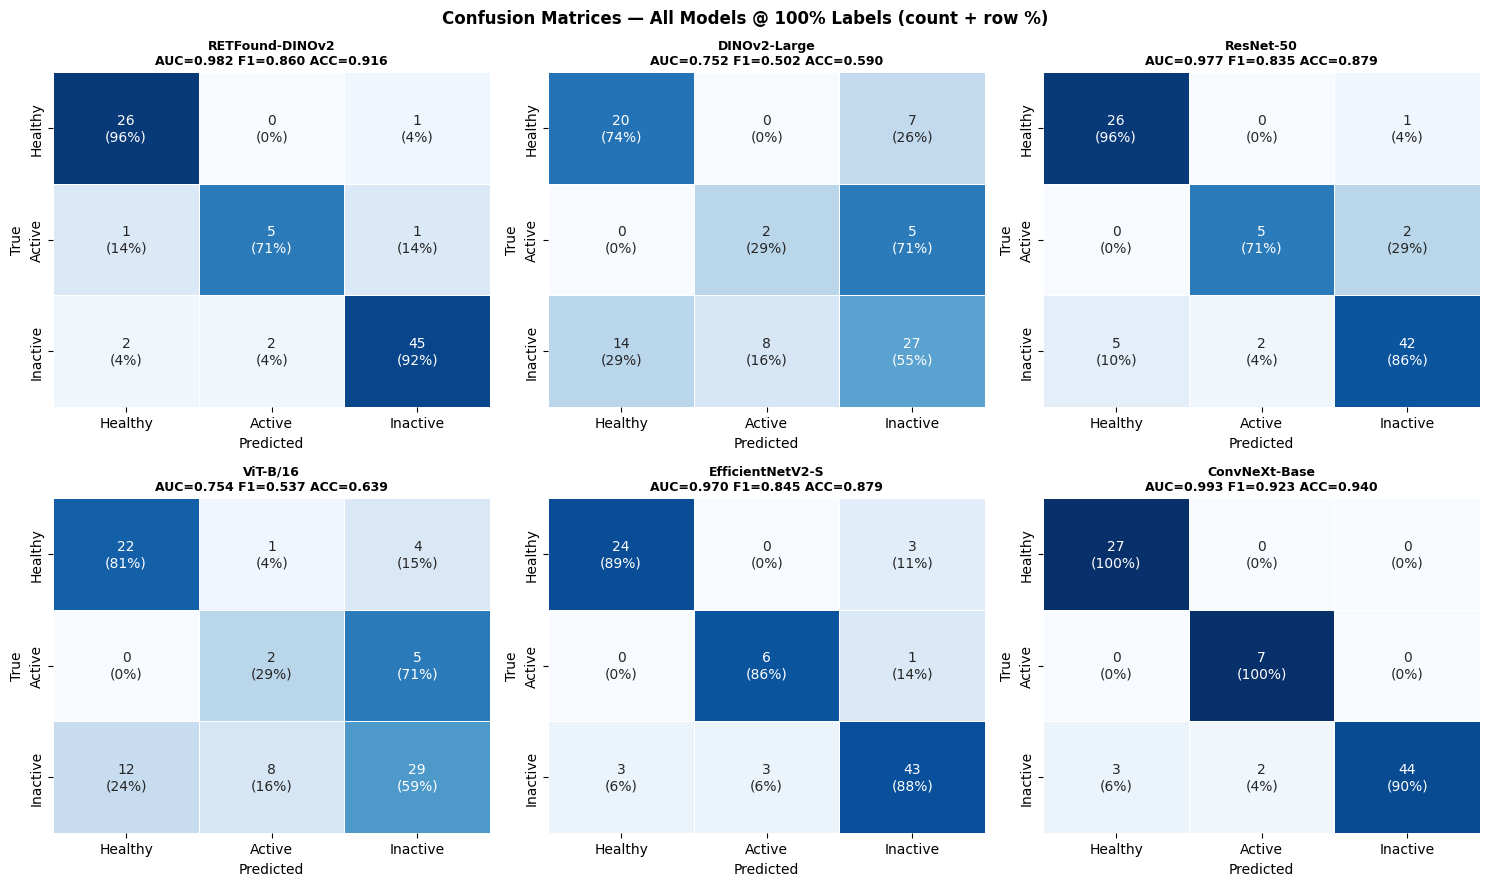

In [14]:
n_m=len(best_models)
fig,axes=plt.subplots(2,3,figsize=(15,9)) if n_m>3 else plt.subplots(1,n_m,figsize=(5*n_m,4.5))
axes=axes.flatten() if n_m>3 else (axes if n_m>1 else [axes])

for ax,(mname,(model,preds,labels,probs)) in zip(axes,best_models.items()):
    cm=confusion_matrix(labels,preds)
    cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True)
    annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(3)] for i in range(3)])
    sns.heatmap(cm_norm,annot=annot,fmt='',cmap='Blues',
                xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
                linewidths=0.5,ax=ax,cbar=False,vmin=0,vmax=1)
    r=results_df[(results_df['Model']==mname)&(results_df['Pct']==100)].iloc[0]
    ax.set_title(f'{mname}\nAUC={r.Test_AUC:.3f} F1={r.Test_F1:.3f} ACC={r.Test_ACC:.3f}',
                 fontweight='bold',fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# Hide unused subplots
for ax in axes[len(best_models):]: ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models @ 100% Labels (count + row %)',
             fontweight='bold',fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/fig4_confusion.png',dpi=150,bbox_inches='tight')
plt.show()

## Cell 15 — Figure 5: Training Curves

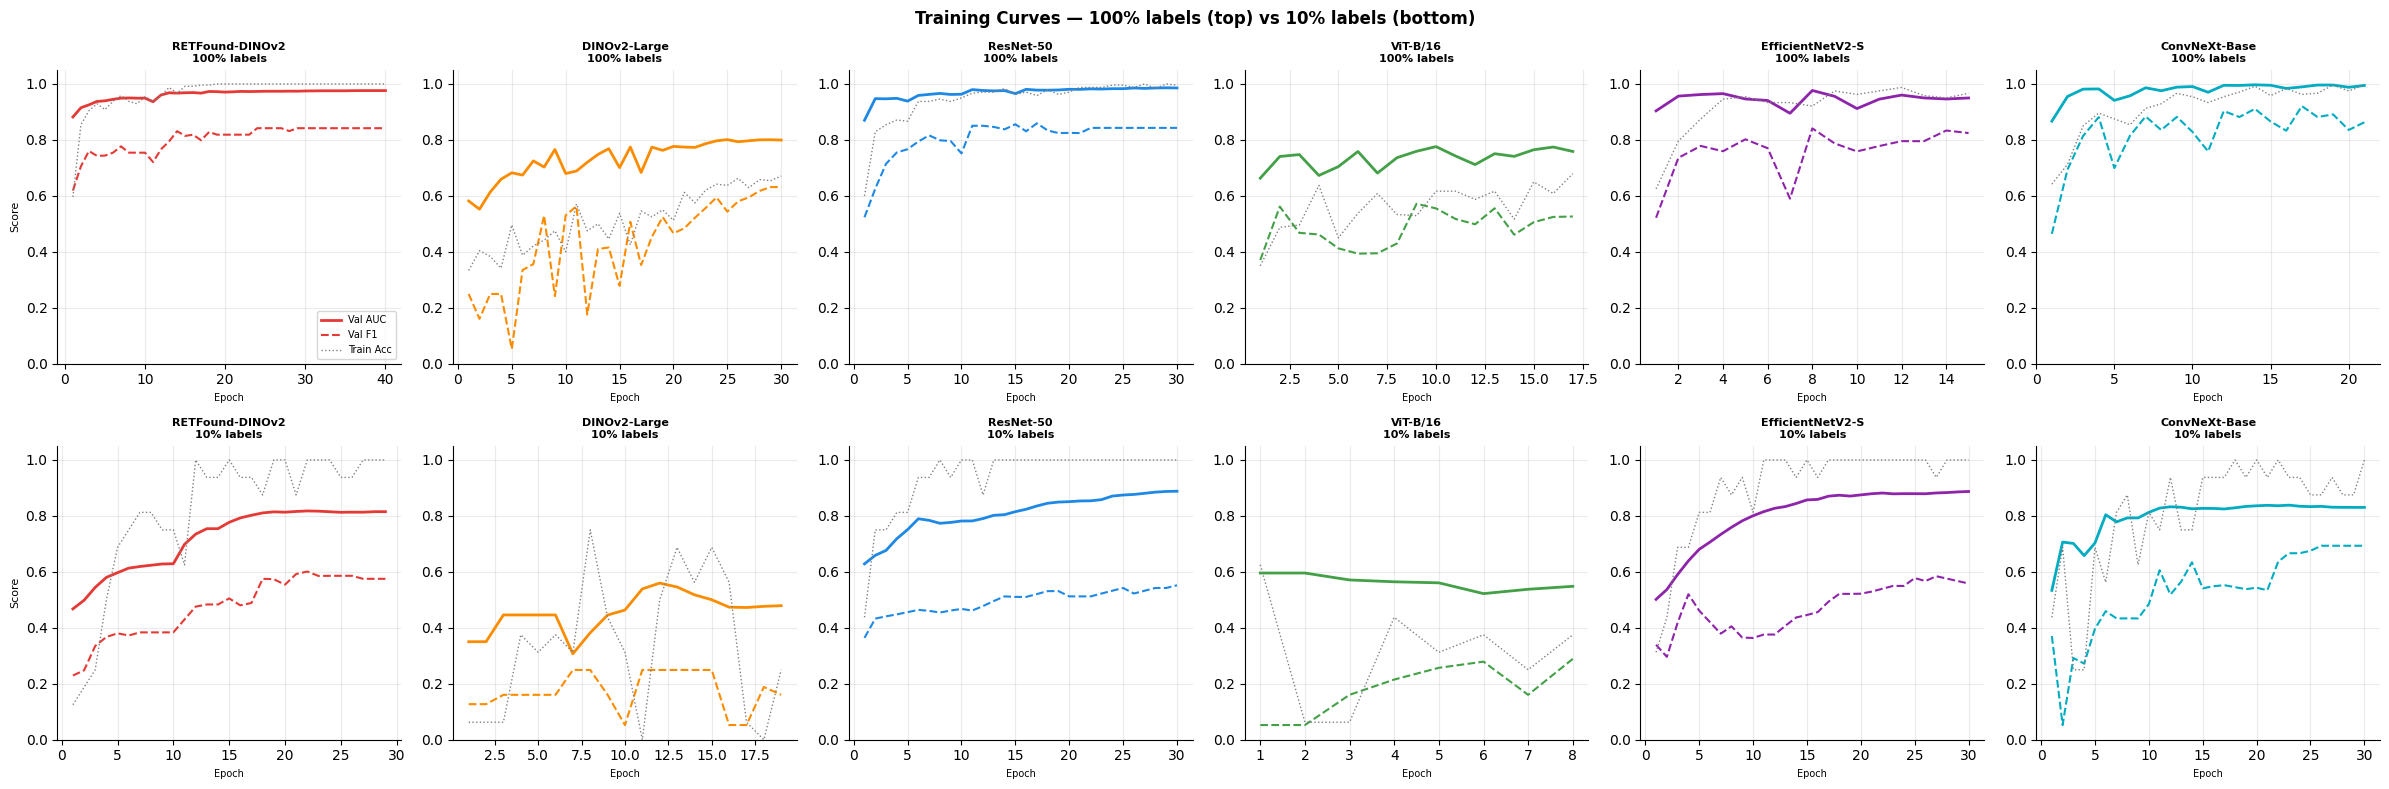

In [15]:
n_models=len(MODEL_REGISTRY)
fig,axes=plt.subplots(2,n_models,figsize=(4*n_models,8))
for col,mname in enumerate(MODEL_REGISTRY):
    for row,frac in enumerate([1.00,0.10]):
        ax=axes[row][col]; key=(mname,frac)
        if key not in all_histories: ax.set_visible(False); continue
        h=all_histories[key]; c=MODEL_COLORS[mname]
        ax.plot(h['epoch'],h['val_auc'],color=c,lw=2,label='Val AUC')
        ax.plot(h['epoch'],h['val_f1'],color=c,lw=1.5,label='Val F1',ls='--')
        ax.plot(h['epoch'],h['tr_acc'],color='gray',lw=1,label='Train Acc',ls=':')
        ax.set_title(f'{mname}\n{int(frac*100)}% labels',fontsize=8,fontweight='bold')
        ax.set_xlabel('Epoch',fontsize=7); ax.set_ylim(0,1.05)
        ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)
        if col==0: ax.set_ylabel('Score',fontsize=8)
        if row==0 and col==0: ax.legend(fontsize=7,loc='lower right')
plt.suptitle('Training Curves — 100% labels (top) vs 10% labels (bottom)',fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fig5_training_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## Cell 16 — Figure 6: Per-Class Performance @ 100% Labels

Per-class classification reports @ 100% labels

── RETFound-DINOv2 ──
              precision    recall  f1-score   support

     Healthy      0.897     0.963     0.929        27
      Active      0.714     0.714     0.714         7
    Inactive      0.957     0.918     0.938        49

    accuracy                          0.916        83
   macro avg      0.856     0.865     0.860        83
weighted avg      0.917     0.916     0.916        83

── DINOv2-Large ──
              precision    recall  f1-score   support

     Healthy      0.588     0.741     0.656        27
      Active      0.200     0.286     0.235         7
    Inactive      0.692     0.551     0.614        49

    accuracy                          0.590        83
   macro avg      0.494     0.526     0.502        83
weighted avg      0.617     0.590     0.595        83

── ResNet-50 ──
              precision    recall  f1-score   support

     Healthy      0.839     0.963     0.897        27
      Active      0.714 

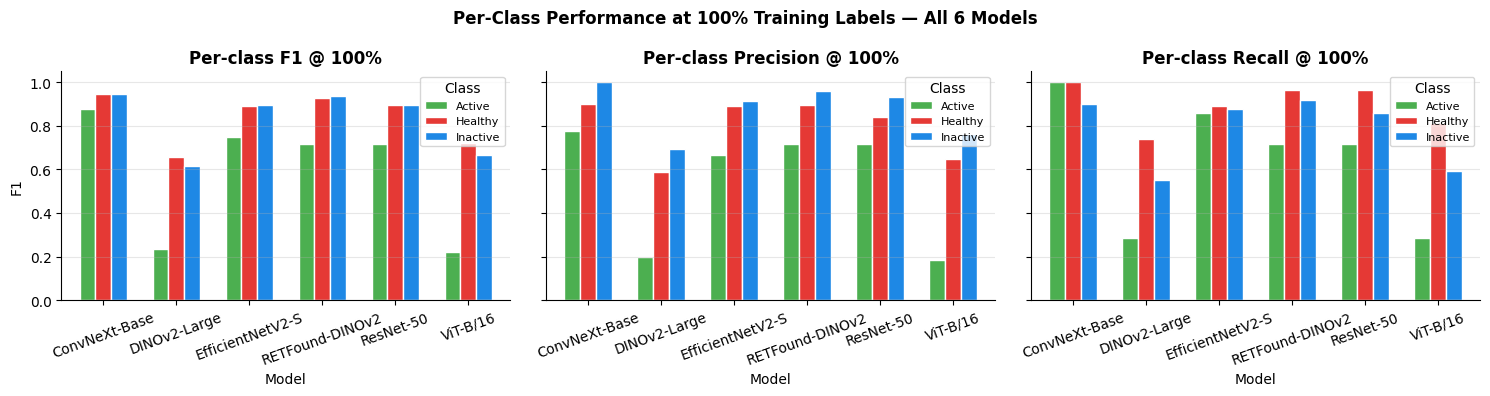

In [16]:
print('Per-class classification reports @ 100% labels\n')
per_class=[]
for mname,(model,preds,labels,_) in best_models.items():
    print(f'── {mname} ──')
    print(classification_report(labels,preds,target_names=CLASS_NAMES,digits=3))
    rep=classification_report(labels,preds,target_names=CLASS_NAMES,output_dict=True)
    for cls in CLASS_NAMES:
        per_class.append({'Model':mname,'Class':cls,
                          'F1':rep[cls]['f1-score'],
                          'Precision':rep[cls]['precision'],
                          'Recall':rep[cls]['recall']})

pcdf=pd.DataFrame(per_class)
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,metric in zip(axes,['F1','Precision','Recall']):
    pivot=pcdf.pivot(index='Model',columns='Class',values=metric)
    pivot.plot(kind='bar',ax=ax,color=PALETTE,edgecolor='white',rot=20,width=0.65)
    ax.set_title(f'Per-class {metric} @ 100%',fontweight='bold')
    ax.set_ylabel(metric); ax.set_ylim(0,1.05)
    ax.legend(title='Class',fontsize=8); ax.grid(axis='y',alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Per-Class Performance at 100% Training Labels — All 6 Models',fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/fig6_perclass.png',dpi=150,bbox_inches='tight')
plt.show()

## Cell 17 — Final Summary

In [17]:
print('='*68)
print('  EXPERIMENT 1 — FINAL SUMMARY (6-Model Comparison)')
print('  Label Efficiency | Ocular Toxoplasmosis | 3-class')
print('='*68)

best=results_df.loc[results_df['Test_AUC'].idxmax()]
print(f'\n Best overall: {best.Model} @ {best.Pct}% labels')
print(f'   AUC={best.Test_AUC:.4f}  F1={best.Test_F1:.4f}  ACC={best.Test_ACC:.4f}')

print('\n── Best model per fraction ──')
for pct in [5,10,25,50,100]:
    sub=results_df[results_df['Pct']==pct]
    if len(sub):
        row=sub.loc[sub['Test_AUC'].idxmax()]
        print(f'  {pct:3d}%  {row.Model:20s}  AUC={row.Test_AUC:.4f}  F1={row.Test_F1:.4f}')

print('\n── AUC heatmap ──')
pivot=results_df.pivot_table(index='Model',columns='Pct',values='Test_AUC').round(3)
pivot.columns=[f'{c}%' for c in pivot.columns]
print(pivot.sort_values('100%',ascending=False).to_string())

print('\n── Label efficiency ratio (AUC@10% / AUC@100%) ──')
for mname in MODEL_REGISTRY:
    r100=results_df[(results_df['Model']==mname)&(results_df['Pct']==100)]
    r10 =results_df[(results_df['Model']==mname)&(results_df['Pct']==10)]
    if len(r100) and len(r10):
        ratio=r10.iloc[0].Test_AUC/r100.iloc[0].Test_AUC
        print(f'  {mname:22s}: {ratio:.3f}  '
              f'({r10.iloc[0].Test_AUC:.3f}@10% vs {r100.iloc[0].Test_AUC:.3f}@100%)')

print('\n── Saved files ──')
for f in sorted(Path('/kaggle/working').glob('fig*.png')):
    print(f'  {f.name}')
print('  experiment1_results.csv')

  EXPERIMENT 1 — FINAL SUMMARY (6-Model Comparison)
  Label Efficiency | Ocular Toxoplasmosis | 3-class

 Best overall: ConvNeXt-Base @ 100% labels
   AUC=0.9933  F1=0.9229  ACC=0.9398

── Best model per fraction ──
    5%  ConvNeXt-Base         AUC=0.8509  F1=0.6681
   10%  ResNet-50             AUC=0.9101  F1=0.5510
   25%  RETFound-DINOv2       AUC=0.9391  F1=0.7172
   50%  EfficientNetV2-S      AUC=0.9760  F1=0.8761
  100%  ConvNeXt-Base         AUC=0.9933  F1=0.9229

── AUC heatmap ──
                     5%    10%    25%    50%   100%
Model                                              
ConvNeXt-Base     0.851  0.909  0.937  0.973  0.993
RETFound-DINOv2   0.834  0.879  0.939  0.964  0.982
ResNet-50         0.740  0.910  0.874  0.952  0.977
EfficientNetV2-S  0.711  0.846  0.899  0.976  0.970
ViT-B/16          0.816  0.602  0.669  0.714  0.754
DINOv2-Large      0.515  0.544  0.559  0.718  0.752

── Label efficiency ratio (AUC@10% / AUC@100%) ──
  RETFound-DINOv2       : 0.895  (0.87